In [1]:
# Imports & paths
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings('ignore') # Suppress clean up warnings

DATA_RAW = Path("../data/raw")
files = [
    "decimal_benign.csv",
    "decimal_DoS.csv",
    "decimal_spoofing-GAS.csv",
    "decimal_spoofing-RPM.csv",
    "decimal_spoofing-SPEED.csv",
    "decimal_spoofing-STEERING_WHEEL.csv"
]

print(pd.read_csv('../data/raw/data_description.csv'), sep=',')

        Column Name                                        Description
0                ID  Indicates the arbitration/priority of the mess...
1  Data_0 to Data_7  Represents Byte 0 through Byte 7 of the data t...
2             label  Identifies the traffic as either benign or mal...
3          category  Identifies the general category to which the t...
4    specific_class  Identifies the specific class of the traffic (...


In [2]:
dfs_clean = []

for file_name in files:
    path = DATA_RAW / file_name
    
    # Read
    df_temp = pd.read_csv(path, dtype=str) 
    # Strip whitespace from ALL column names
    df_temp.columns = df_temp.columns.str.strip()
    
    # Drop any duplicate columns that might still exist after rename
    # (keeps the first occurrence)
    df_temp = df_temp.loc[:, ~df_temp.columns.duplicated()]
    
    # Step 4: Add source tracking
    df_temp['source_file'] = file_name
    
    # Optional: Ensure core columns exist
    expected = ['ID', 'DATA_0', 'DATA_1', 'DATA_2', 'DATA_3',
                'DATA_4', 'DATA_5', 'DATA_6', 'DATA_7', 'label', 'category', 'specific_class', 'source_file']
    missing = [col for col in expected if col not in df_temp.columns]
    if missing:
        print(f"Warning: {file_name} missing columns: {missing}")
    else:
        print("No missing columns.")
    
    dfs_clean.append(df_temp)

# Concatenate
df = pd.concat(dfs_clean, ignore_index=True)


# checks

print("\nFinal shape:", df.shape)
print("Final columns:", df.columns.tolist())
print("\nUnique labels:", sorted(df['label'].unique()))
print("\nUnique categories:", df['category'].dropna().unique() if 'category' in df else "No category column")
print("\nUnique specific_classes:", df['specific_class'].dropna().unique() if 'specific_class' in df else "No specific_class column")

No missing columns.
No missing columns.
No missing columns.
No missing columns.
No missing columns.
No missing columns.

Final shape: (1408219, 13)
Final columns: ['ID', 'DATA_0', 'DATA_1', 'DATA_2', 'DATA_3', 'DATA_4', 'DATA_5', 'DATA_6', 'DATA_7', 'label', 'category', 'specific_class', 'source_file']

Unique labels: [' ATTACK', 'ATTACK', 'BENIGN']

Unique categories: <StringArray>
['BENIGN', ' DoS     ', 'SPOOFING']
Length: 3, dtype: str

Unique specific_classes: <StringArray>
['BENIGN', ' DoS', 'GAS', 'RPM', 'SPEED', 'STEERING_WHEEL']
Length: 6, dtype: str


In [3]:
# Final label/category/specific_class cleaning and normalization
df['label'] = df['label'].str.strip().str.upper()
df['category'] = df['category'].str.strip().str.upper()
df['specific_class'] = df['specific_class'].str.strip().str.upper()
# Optional: Create binary target for quick baseline (if you want binary first)
df['is_attack'] = (df['label'] == 'ATTACK').astype(int)

# FInal checks
print("Final shape:", df.shape)
print("Final columns:", df.columns.tolist())
print("\nUnique labels:", sorted(df['label'].unique()))
print("\nUnique categories:", df['category'].dropna().unique() if 'category' in df else "No category column")
print("\nUnique specific_classes:", df['specific_class'].dropna().unique() if 'specific_class' in df else "No specific_class column")

Final shape: (1408219, 14)
Final columns: ['ID', 'DATA_0', 'DATA_1', 'DATA_2', 'DATA_3', 'DATA_4', 'DATA_5', 'DATA_6', 'DATA_7', 'label', 'category', 'specific_class', 'source_file', 'is_attack']

Unique labels: ['ATTACK', 'BENIGN']

Unique categories: <StringArray>
['BENIGN', 'DOS', 'SPOOFING']
Length: 3, dtype: str

Unique specific_classes: <StringArray>
['BENIGN', 'DOS', 'GAS', 'RPM', 'SPEED', 'STEERING_WHEEL']
Length: 6, dtype: str


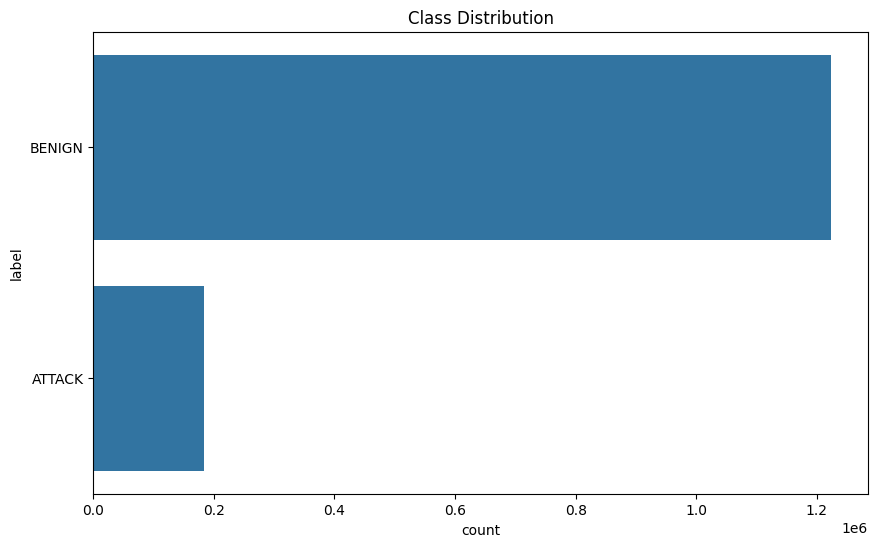

In [4]:
# Quick visuals
plt.figure(figsize=(10,6))
sns.countplot(y='label', data=df, order=df['label'].value_counts().index)
plt.title("Class Distribution")
plt.show()

In [5]:
df.head()

,ID,DATA_0,DATA_1,DATA_2,DATA_3,DATA_4,DATA_5,DATA_6,DATA_7,label,category,specific_class,source_file,is_attack
0,65,96,0,0,0,0,0,0,0,BENIGN,BENIGN,BENIGN,decimal_benign.csv,0
1,1068,132,13,160,0,0,0,0,0,BENIGN,BENIGN,BENIGN,decimal_benign.csv,0
2,535,127,255,127,255,127,255,127,255,BENIGN,BENIGN,BENIGN,decimal_benign.csv,0
3,131,15,224,0,0,0,0,0,0,BENIGN,BENIGN,BENIGN,decimal_benign.csv,0
4,936,1,0,39,16,0,0,0,0,BENIGN,BENIGN,BENIGN,decimal_benign.csv,0


In [6]:
# Convert numerics
num_cols = ['ID', 'DATA_0', 'DATA_1', 'DATA_2', 'DATA_3', 'DATA_4', 'DATA_5', 'DATA_6', 'DATA_7']
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce', downcast='integer')

#Duplicates check
print("Final shape:", df.shape)
print("Full duplicates:", df.duplicated().sum())                    # Likely very high
print("Duplicates ignoring label/category:", df.drop(['label','category','specific_class','source_file'], axis=1).duplicated().sum())

Final shape: (1408219, 14)
Full duplicates: 1404631
Duplicates ignoring label/category: 1404631


In [7]:
# Save this new dataset specifically for the Federated simulation (no longer need)
df.to_csv("../data/processed/IoV_rawAllClasses.csv", index=False)

## Per-Class Deduplication → reserve up to 100 times Unique Signature traffic per Class
### For Federated Learning Pipeline, this dataset will be splitted into 5 clients and server

In [8]:
# retaining signature cols
signature_cols = ['ID', 'DATA_0', 'DATA_1', 'DATA_2', 'DATA_3', 'DATA_4', 'DATA_5', 'DATA_6', 'DATA_7']
group_key = 'specific_class'
classes = ['BENIGN', 'DOS', 'GAS', 'RPM', 'SPEED', 'STEERING_WHEEL']

dfs_deduped = []

for cls in classes:
    # Subset for this class
    df_cls = df[df[group_key] == cls].copy()
    orig_rows = len(df_cls)
    
    # Group by the signature and keep up to the first 5 occurrences
    df_cls_dedup = df_cls.groupby(signature_cols).head(100)
    
    dedup_rows = len(df_cls_dedup)
    removed = orig_rows - dedup_rows
    
    print(f"{cls:16} | Original: {orig_rows:>8,} | After 100x cap: {dedup_rows:>6,} | Removed: {removed:>6,}")
    
    dfs_deduped.append(df_cls_dedup)

# Concatenate all deduplicated subsets
df_dedup_per_class = pd.concat(dfs_deduped, ignore_index=True)

print("\n" + "="*60)
print(f"Final 100x capped shape: {df_dedup_per_class.shape}")

# Save this new dataset specifically for the Federated simulation
df_dedup_per_class.to_csv("../data/processed/df_federated_100x.csv", index=False)

BENIGN           | Original: 1,223,737 | After 100x cap: 23,313 | Removed: 1,200,424
DOS              | Original:   74,663 | After 100x cap:  2,004 | Removed: 72,659
GAS              | Original:    9,991 | After 100x cap:    200 | Removed:  9,791
RPM              | Original:   54,900 | After 100x cap:    906 | Removed: 53,994
SPEED            | Original:   24,951 | After 100x cap:    500 | Removed: 24,451
STEERING_WHEEL   | Original:   19,977 | After 100x cap:    208 | Removed: 19,769

Final 100x capped shape: (27131, 14)


In [9]:
df_dedup_per_class.tail()

,ID,DATA_0,DATA_1,DATA_2,DATA_3,DATA_4,DATA_5,DATA_6,DATA_7,label,category,specific_class,source_file,is_attack
27126,128,0,0,0,0,0,0,0,0,ATTACK,SPOOFING,STEERING_WHEEL,decimal_spoofing-STEERING_WHEEL.csv,1
27127,128,0,0,0,0,0,0,0,0,ATTACK,SPOOFING,STEERING_WHEEL,decimal_spoofing-STEERING_WHEEL.csv,1
27128,128,0,0,0,0,0,0,0,0,ATTACK,SPOOFING,STEERING_WHEEL,decimal_spoofing-STEERING_WHEEL.csv,1
27129,128,0,0,0,0,0,0,0,0,ATTACK,SPOOFING,STEERING_WHEEL,decimal_spoofing-STEERING_WHEEL.csv,1
27130,128,0,0,0,0,0,0,0,0,ATTACK,SPOOFING,STEERING_WHEEL,decimal_spoofing-STEERING_WHEEL.csv,1


In [10]:
import os
import pandas as pd
from sklearn.model_selection import StratifiedKFold

# Configuration
input_file = '../data/processed/df_federated_100x.csv'
output_dir = '../data/processed/'
num_nodes = 5

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load master dataset
print(f"Loading {input_file}...")
df = pd.read_csv(input_file)

# Stratified split
# We use node_id 1-indexed to match NVFLARE's 'site-1', 'site-2', etc.
skf = StratifiedKFold(n_splits=num_nodes, shuffle=True, random_state=42)

print(f"Splitting into {num_nodes} balanced shards...")
# skf.split returns indices. We enumerate to get the shard number.
for i, (_, indices) in enumerate(skf.split(df, df['specific_class']), 1):
    shard = df.iloc[indices].copy()
    
    # Define filename (e.g., vehicle_site-1_train.csv)
    file_name = f"vehicle_site-{i}_train.csv"
    file_path = os.path.join(output_dir, file_name)
    
    # Save to CSV
    #shard.to_csv(file_path, index=False)
    #print(f"Saved Shard {i}: {file_path} ({len(shard)} rows)")

print("\nData preparation complete for 5 vehicles.")

Loading ../data/processed/df_federated_100x.csv...
Splitting into 5 balanced shards...

Data preparation complete for 5 vehicles.


## EXPERIMENT: Which model perform best f1 score to create best feature engineering prob_ATTACK and prob_BENIGN cols

In [11]:
# dependencies
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import f1_score, log_loss
from IPython.display import display

# load dataset
df_experiment = df_dedup_per_class.copy()

In [12]:
# prepare X and y
feature_cols = ['ID', 'DATA_0', 'DATA_1', 'DATA_2', 'DATA_3', 'DATA_4', 'DATA_5', 'DATA_6', 'DATA_7']
X = df_experiment[feature_cols]
y = df_experiment['is_attack']

# Calculate the exact ratio of benign to attack for XGBoost to handle class imbalance
ratio = float(np.sum(y == 0)) / np.sum(y==1) if np.sum(y==1) > 0 else 1.0


# define the models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight='balanced', random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    "XGBoost": xgb.XGBClassifier(
        scale_pos_weight=ratio, eval_metrics='logloss', random_state=42, n_jobs=-1
    ),
    "LightGBM": lgb.LGBMClassifier(
        class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
    )
}

# Cross validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run to compare models
print("Starting Model Experiment for Binary Classification (ATTACK vs BENIGN)...")
print(f"Total rows: {len(X):,} | Features used: {feature_cols}")
print("v"*100)
print(f"{'Model Name': <22} | {'Mean Macro F1': <18} | {'Mean Binary F1': <20}")
print("^"*100)

results = []

for name, model in models.items():
    scoring = ['f1_macro', 'f1']

    cv_results = cross_validate(model, X, y, cv=skf, scoring=scoring, n_jobs=-1)

    mean_f1_macro = np.mean(cv_results['test_f1_macro'])
    mean_f1_binary = np.mean(cv_results['test_f1'])

    results.append({
        'Model': name,
        'F1_macro': mean_f1_macro,
        'F1_Attack_Binary': mean_f1_binary
    })

    print(f"{name:<22} | {mean_f1_macro:.4f}             | {mean_f1_binary:.4f}")

# display the final scores
print("v"*100)
results_df = pd.DataFrame(results).sort_values(by='F1_macro', ascending=False).reset_index(drop=True)
print("\nBenchmarch Board (sorted by f1 macro descending):")
display(results_df)

Starting Model Experiment for Binary Classification (ATTACK vs BENIGN)...
Total rows: 27,131 | Features used: ['ID', 'DATA_0', 'DATA_1', 'DATA_2', 'DATA_3', 'DATA_4', 'DATA_5', 'DATA_6', 'DATA_7']
vvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvv
Model Name             | Mean Macro F1      | Mean Binary F1      
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Logistic Regression    | 0.8544             | 0.7587
Decision Tree          | 1.0000             | 1.0000
Random Forest          | 1.0000             | 1.0000
Gradient Boosting      | 1.0000             | 1.0000
XGBoost                | 1.0000             | 1.0000
LightGBM               | 1.0000             | 1.0000
vvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvv

Benchmarch Board (sorted by f1 macro descending):


,Model,F1_macro,F1_Attack_Binary
0,Decision Tree,1.000000,1.000000
1,Random Forest,1.000000,1.000000
2,XGBoost,1.000000,1.000000
3,Gradient Boosting,1.000000,1.000000
4,LightGBM,1.000000,1.000000
5,Logistic Regression,0.854359,0.758739


In [13]:
# investigating the Random Forest to see how it got a perfect 1.0
rf_model = models["Random Forest"]
rf_model.fit(X, y) # the whole dataset

# Extract and sort the feature importances
importance_df = pd.DataFrame({
    'Feature': feature_cols, 
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("🔍 FEATURE IMPORTANCE (What the model used to cheat):")
display(importance_df)

🔍 FEATURE IMPORTANCE (What the model used to cheat):


,Feature,Importance
0,ID,0.457217
1,DATA_1,0.197055
2,DATA_0,0.104739
3,DATA_5,0.052603
4,DATA_7,0.050355
5,DATA_6,0.050150
6,DATA_2,0.035111
7,DATA_3,0.028025
8,DATA_4,0.024745


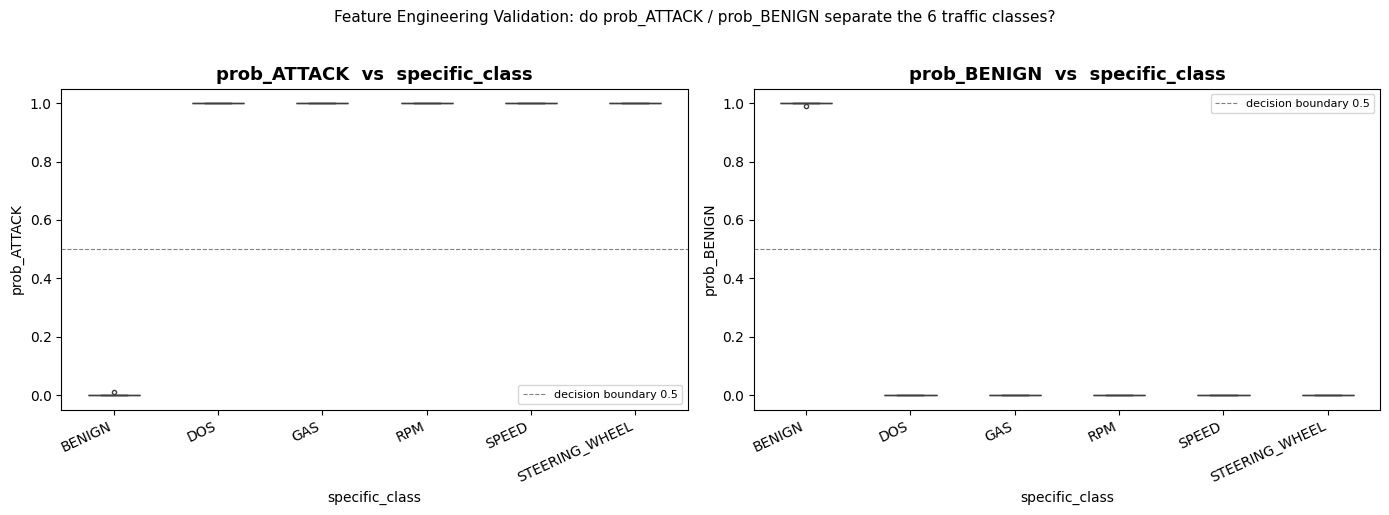

Mean probability per class:


,prob_ATTACK mean,prob_ATTACK std,prob_BENIGN mean,prob_BENIGN std
specific_class,,,,
BENIGN,0.0,0.0001,1.0,0.0001
DOS,1.0,0.0000,0.0,0.0000
GAS,1.0,0.0000,0.0,0.0000
RPM,1.0,0.0000,0.0,0.0000
SPEED,1.0,0.0000,0.0,0.0000
STEERING_WHEEL,1.0,0.0000,0.0,0.0000


In [14]:
# ── How prob_ATTACK & prob_BENIGN separate the 6 specific_class traffic types ──
# rf_model is already fitted on X (full deduplicated dataset) above.
# Generate probabilities for every row in df_experiment.

proba = rf_model.predict_proba(X)                       # shape (N, 2)
# rf_model.classes_ order is [0=BENIGN, 1=ATTACK]
prob_df = df_experiment[["specific_class"]].copy()
prob_df["prob_BENIGN"] = proba[:, 0]
prob_df["prob_ATTACK"] = proba[:, 1]

CLASS_ORDER = ["BENIGN", "DOS", "GAS", "RPM", "SPEED", "STEERING_WHEEL"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat, title in zip(
    axes,
    ["prob_ATTACK", "prob_BENIGN"],
    ["prob_ATTACK  vs  specific_class", "prob_BENIGN  vs  specific_class"]
):
    sns.boxplot(
        data=prob_df, x="specific_class", y=feat,
        order=CLASS_ORDER,
        width=0.5, fliersize=3, ax=ax
    )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("specific_class")
    ax.set_ylabel(feat)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="decision boundary 0.5")
    ax.legend(fontsize=8)

plt.suptitle(
    "Feature Engineering Validation: do prob_ATTACK / prob_BENIGN separate the 6 traffic classes?",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

# ── Summary table: mean probability per class ──────────────────────────────────
summary = (
    prob_df.groupby("specific_class")[["prob_ATTACK", "prob_BENIGN"]]
    .agg(["mean", "std"])
    .round(4)
)
summary.columns = ["prob_ATTACK mean", "prob_ATTACK std", "prob_BENIGN mean", "prob_BENIGN std"]
summary = summary.reindex(CLASS_ORDER)
print("Mean probability per class:")
display(summary)

## Per-Class Deduplication → Preserve Unique Signatures per Class
### For experiment centralized mode

In [15]:
# Define what constitutes a "signature"
signature_cols = ['ID', 'DATA_0', 'DATA_1', 'DATA_2', 'DATA_3', 'DATA_4', 'DATA_5', 'DATA_6', 'DATA_7']

# use 'specific_class' as the grouping key
group_key = 'specific_class'

# List of classes
classes = ['BENIGN', 'DOS', 'GAS', 'RPM', 'SPEED', 'STEERING_WHEEL']

dfs_deduped = []

for cls in classes:
    # Subset for this class
    df_cls = df[df[group_key] == cls].copy()
    
    orig_rows = len(df_cls)
    
    # Deduplicate within this class only
    df_cls_dedup = df_cls.drop_duplicates(subset=signature_cols)
    
    dedup_rows = len(df_cls_dedup)
    removed = orig_rows - dedup_rows
    
    print(f"{cls:16} | Original: {orig_rows:>8,} | After dedup: {dedup_rows:>6,} | Removed: {removed:>6,}")
    
    dfs_deduped.append(df_cls_dedup)

# Concatenate all deduplicated subsets
df_dedup_per_class = pd.concat(dfs_deduped, ignore_index=True)

print("\n" + "="*60)
print(f"Final deduplicated shape: {df_dedup_per_class.shape}")
print(f"Total unique signatures across classes: {len(df_dedup_per_class):,}")

# Distribution after per-class dedup
print("\nFinal class distribution:")
print(df_dedup_per_class[group_key].value_counts().to_frame(name='count'))

BENIGN           | Original:   23,313 | After dedup:  3,547 | Removed: 19,766
DOS              | Original:    2,004 | After dedup:     21 | Removed:  1,983
GAS              | Original:      200 | After dedup:      2 | Removed:    198
RPM              | Original:      906 | After dedup:     10 | Removed:    896
SPEED            | Original:      500 | After dedup:      5 | Removed:    495
STEERING_WHEEL   | Original:      208 | After dedup:      3 | Removed:    205

Final deduplicated shape: (3588, 14)
Total unique signatures across classes: 3,588

Final class distribution:
                count
specific_class       
BENIGN           3547
DOS                21
RPM                10
SPEED               5
STEERING_WHEEL      3
GAS                 2


# Nested Cross-Validation for Meta-Model

In [16]:
# Use the deduplicated dataset (unique signatures)
df_master = df_dedup_per_class.copy()

# Define features
X = df_master[signature_cols].copy()

# Setup Inner Target label
inner_target_col = 'label'
le_inner = LabelEncoder()
y_inner = le_inner.fit_transform(df_master[inner_target_col])
inner_classes = le_inner.classes_

# Setup Outer Target specific_class
outer_target_col = 'specific_class'
le_outer = LabelEncoder()
y_outer = le_outer.fit_transform(df_master[outer_target_col])

# Initialize the Outer Loop (k=5)
outer_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
macro_f1_scores = []

print("Data alignment complete. Inner and Outer targets prepared!")

Data alignment complete. Inner and Outer targets prepared!


In [ ]:
# save f1 scores
macro_f1_scores = []

# Outer loop: k=5 for predicting specific_class
for outer_fold, (train_idx, test_idx) in enumerate(outer_skf.split(X, y_outer)):
    
    print(f"Outer Fold {outer_fold + 1}/5")
    
    # Split data for the outer fold
    X_train_outer = X.iloc[train_idx].copy()
    y_train_outer = y_outer[train_idx]
    # Also split the inner target (label) for the training data
    y_train_inner = y_inner[train_idx]
    
    X_test_outer = X.iloc[test_idx].copy()
    y_test_outer = y_outer[test_idx]
    
    # Inner Loop Setup (k=5) to create attackProbability feature for X_train_outer safely
    print("  -> Starting Inner CV (k=5) for attack probability feature...")
    inner_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # Array to hold the out-of-fold probabilities for the training set
    oof_probs_train = np.zeros((len(X_train_outer), len(inner_classes)), dtype=float)
    
    for inner_fold, (inner_tr_idx, inner_val_idx) in enumerate(inner_skf.split(X_train_outer, y_train_inner)):
        X_tr_inner, X_val_inner = X_train_outer.iloc[inner_tr_idx], X_train_outer.iloc[inner_val_idx]
        y_tr_inner = y_train_inner[inner_tr_idx]

        # Train model to predict general 'label'
        inner_model = RandomForestClassifier(
            n_estimators=80,max_depth=7,
            class_weight='balanced_subsample', random_state=42, n_jobs=-1)
        
        inner_model.fit(X_tr_inner[signature_cols], y_tr_inner)
        
        # Predict probabilities for the validation fold
        oof_probs_train[inner_val_idx] = inner_model.predict_proba(X_val_inner[signature_cols])
        
    # Add the probabilities as new features to X_train_outer
    for i, cls_name in enumerate(inner_classes):
        X_train_outer[f'prob_{cls_name}'] = oof_probs_train[:, i]
        
    # Generate attack and benign Probability features for X_test_outer
    print("  -> Training bridge model to generate features for test set...")
    bridge_model = RandomForestClassifier(
        
        n_estimators=80, max_depth=7,
        class_weight='balanced_subsample', random_state=42, n_jobs=-1)
    
    bridge_model.fit(X_train_outer[signature_cols], y_train_inner) # Train only on original features
    
    # Predict on test set
    test_probs = bridge_model.predict_proba(X_test_outer[signature_cols])
    for i, cls_name in enumerate(inner_classes):
        X_test_outer[f'prob_{cls_name}'] = test_probs[:, i]
        
    # ANOVA Feature Selection on original features + probability features
    print("  -> Running ANOVA feature selection...")
    selector = SelectKBest(f_classif, k='all')
    selector.fit(X_train_outer, y_train_outer)
    
    # Select top features (p < 0.05)
    p_values = pd.Series(selector.pvalues_, index=X_train_outer.columns)
    selected_features = p_values[p_values < 0.05].index.tolist()
    
    # Fallback if too few features selected
    if len(selected_features) < 4:
        feat_scores = pd.Series(selector.scores_, index=X_train_outer.columns).sort_values(ascending=False)
        selected_features = feat_scores.head(6).index.tolist()
        
    print(f"  -> Selected features: {selected_features}")
    
    # Train Final Meta-Model and Predict
    print("  -> Training final meta-model on selected features...")
    meta_rf = RandomForestClassifier(
        n_estimators=200, 
        class_weight='balanced_subsample', 
        max_depth=7, 
        min_samples_leaf=2, 
        random_state=42, 
        n_jobs=-1
    )
    
    # Train using only the ANOVA selected features
    meta_rf.fit(X_train_outer[selected_features], y_train_outer)
    
    # Predict on test set using the same selected features
    y_pred = meta_rf.predict(X_test_outer[selected_features])
    
    # Evaluate
    f1 = f1_score(y_test_outer, y_pred, average='macro', zero_division=0)
    macro_f1_scores.append(f1)
    print(f"  -> Outer Fold {outer_fold + 1} Macro-F1: {f1:.4f}")

print("\n" + "="*40)
print("Final CV Macro-F1 mean ± std: {:.4f} ± {:.4f}".format(np.mean(macro_f1_scores), np.std(macro_f1_scores)))

Outer Fold 1/5
  -> Starting Inner CV (k=5) for attack probability feature...
  -> Training bridge model to generate features for test set...
  -> Running ANOVA feature selection...
  -> Selected features: ['ID', 'DATA_0', 'DATA_2', 'DATA_3', 'DATA_4', 'DATA_7', 'prob_ATTACK', 'prob_BENIGN']
  -> Training final meta-model on selected features...
  -> Outer Fold 1 Macro-F1: 0.8667
Outer Fold 2/5
  -> Starting Inner CV (k=5) for attack probability feature...
  -> Training bridge model to generate features for test set...
  -> Running ANOVA feature selection...
  -> Selected features: ['ID', 'DATA_0', 'DATA_2', 'DATA_3', 'DATA_4', 'DATA_6', 'DATA_7', 'prob_ATTACK', 'prob_BENIGN']
  -> Training final meta-model on selected features...
  -> Outer Fold 2 Macro-F1: 0.7778
Outer Fold 3/5
  -> Starting Inner CV (k=5) for attack probability feature...
  -> Training bridge model to generate features for test set...
  -> Running ANOVA feature selection...
  -> Selected features: ['ID', 'DATA_0', '

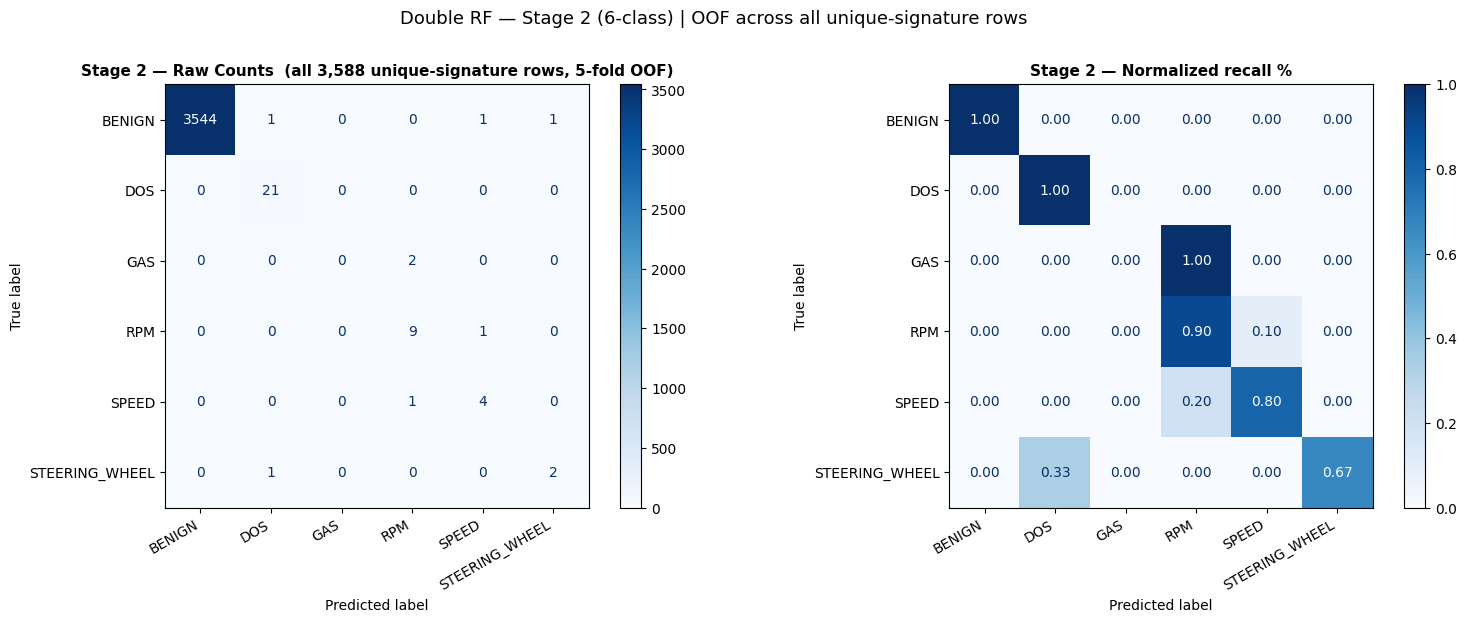

In [18]:
# ── Stage 2 Confusion Matrix — OOF predictions across all 5 outer folds ─────
# Reuses the nested CV structure to collect predictions for ALL 3,588 rows.
# Every row is a test sample in exactly one fold → no data wasted.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

oof_true = np.zeros(len(df_master), dtype=int)
oof_pred = np.zeros(len(df_master), dtype=int)

for outer_fold, (train_idx, test_idx) in enumerate(outer_skf.split(X, y_outer)):
    X_tr = X.iloc[train_idx].copy();  y_tr_in = y_inner[train_idx];  y_tr_out = y_outer[train_idx]
    X_te = X.iloc[test_idx].copy()

    # Inner CV — OOF prob features for train set
    inner_skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_probs  = np.zeros((len(X_tr), 2))
    for itr, ival in inner_skf2.split(X_tr, y_tr_in):
        im = RandomForestClassifier(n_estimators=80, max_depth=7,
                                    class_weight="balanced_subsample", random_state=42, n_jobs=-1)
        im.fit(X_tr.iloc[itr], y_tr_in[itr])
        oof_probs[ival] = im.predict_proba(X_tr.iloc[ival])

    X_tr_aug = X_tr.copy()
    X_te_aug  = X_te.copy()
    for i, cls in enumerate(le_inner.classes_):
        X_tr_aug[f"prob_{cls}"] = oof_probs[:, i]

    # Bridge model for test prob features
    bm = RandomForestClassifier(n_estimators=80, max_depth=7,
                                class_weight="balanced_subsample", random_state=42, n_jobs=-1)
    bm.fit(X_tr[signature_cols], y_tr_in)
    for i, cls in enumerate(le_inner.classes_):
        X_te_aug[f"prob_{cls}"] = bm.predict_proba(X_te)[:, i]

    # ANOVA selection
    sel = SelectKBest(f_classif, k="all").fit(X_tr_aug, y_tr_out)
    p_vals   = pd.Series(sel.pvalues_, index=X_tr_aug.columns)
    selected = p_vals[p_vals < 0.05].index.tolist()
    if len(selected) < 4:
        selected = pd.Series(sel.scores_, index=X_tr_aug.columns).nlargest(6).index.tolist()

    # Stage 2 meta RF
    meta = RandomForestClassifier(n_estimators=200, class_weight="balanced_subsample",
                                  max_depth=7, min_samples_leaf=2, random_state=42, n_jobs=-1)
    meta.fit(X_tr_aug[selected], y_tr_out)

    oof_true[test_idx] = y_outer[test_idx]
    oof_pred[test_idx] = meta.predict(X_te_aug[selected])

# ── Plot ───────────────────────────────────────────────────────────────────────
class_names = le_outer.classes_
cm_raw  = confusion_matrix(oof_true, oof_pred)
cm_norm = confusion_matrix(oof_true, oof_pred, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, cm, title, fmt in zip(
    axes,
    [cm_raw,  cm_norm],
    ["Stage 2 — Raw Counts  (all 3,588 unique-signature rows, 5-fold OOF)",
     "Stage 2 — Normalized recall %"],
    ["d", ".2f"]
):
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
        ax=ax, colorbar=True, cmap="Blues", values_format=fmt)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xticklabels(class_names, rotation=30, ha="right")

plt.suptitle("Double RF — Stage 2 (6-class) | OOF across all unique-signature rows", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

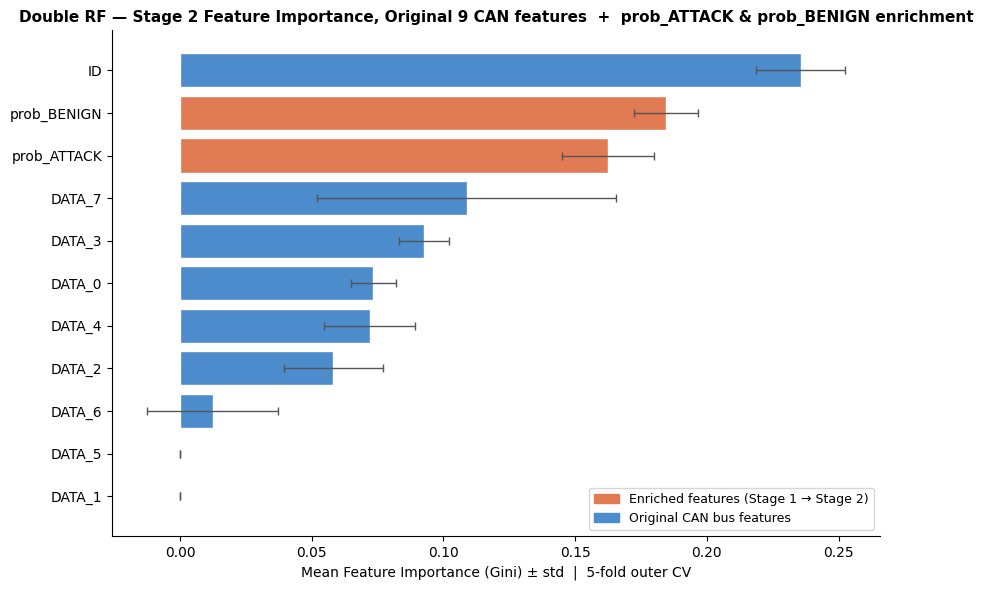

Feature importance (mean ± std, descending):


,feature,mean,std
0,ID,0.2355,0.0169
1,prob_BENIGN,0.1845,0.0122
2,prob_ATTACK,0.1624,0.0176
3,DATA_7,0.1088,0.0567
4,DATA_3,0.0928,0.0095
5,DATA_0,0.0734,0.0084
6,DATA_4,0.0720,0.0172
7,DATA_2,0.0582,0.0188
8,DATA_6,0.0125,0.0249
9,DATA_5,0.0000,0.0000


In [19]:
# ── Stage 2 Feature Importance — original 9 CAN features + prob_ATTACK & prob_BENIGN ──
# Re-runs the outer CV (5 folds), collects meta_RF importances per fold.
# Final chart shows mean ± std across 5 folds; enriched features highlighted.
import matplotlib.patches as mpatches

all_features = signature_cols + [f"prob_{c}" for c in le_inner.classes_]
importance_matrix = np.zeros((5, len(all_features)))  # shape: (folds, features)

for fold_idx, (train_idx, test_idx) in enumerate(outer_skf.split(X, y_outer)):
    X_tr = X.iloc[train_idx].copy()
    y_tr_in  = y_inner[train_idx]
    y_tr_out = y_outer[train_idx]

    # Inner CV — OOF prob features for train set (avoids leakage)
    inner_skf_fi = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_probs_fi = np.zeros((len(X_tr), len(le_inner.classes_)))
    for itr, ival in inner_skf_fi.split(X_tr, y_tr_in):
        im = RandomForestClassifier(n_estimators=80, max_depth=7,
                                    class_weight="balanced_subsample", random_state=42, n_jobs=-1)
        im.fit(X_tr.iloc[itr], y_tr_in[itr])
        oof_probs_fi[ival] = im.predict_proba(X_tr.iloc[ival])

    X_tr_aug = X_tr.copy()
    for i, cls in enumerate(le_inner.classes_):
        X_tr_aug[f"prob_{cls}"] = oof_probs_fi[:, i]

    # ANOVA feature selection (same logic as main nested CV)
    sel = SelectKBest(f_classif, k="all").fit(X_tr_aug, y_tr_out)
    p_vals   = pd.Series(sel.pvalues_, index=X_tr_aug.columns)
    selected = p_vals[p_vals < 0.05].index.tolist()
    if len(selected) < 4:
        selected = pd.Series(sel.scores_, index=X_tr_aug.columns).nlargest(6).index.tolist()

    # Train meta RF on selected features, collect importances
    meta = RandomForestClassifier(n_estimators=200, class_weight="balanced_subsample",
                                  max_depth=7, min_samples_leaf=2, random_state=42, n_jobs=-1)
    meta.fit(X_tr_aug[selected], y_tr_out)

    # Map fold importances back to the full 11-feature list (0 for unselected)
    imp_map = dict(zip(selected, meta.feature_importances_))
    for j, feat in enumerate(all_features):
        importance_matrix[fold_idx, j] = imp_map.get(feat, 0.0)

# summary
mean_imp = importance_matrix.mean(axis=0)
std_imp  = importance_matrix.std(axis=0)
feat_df  = pd.DataFrame({"feature": all_features, "mean": mean_imp, "std": std_imp})
feat_df  = feat_df.sort_values("mean", ascending=True).reset_index(drop=True)

enriched_feats = {f"prob_{c}" for c in le_inner.classes_}
colors = ["#E07B54" if f in enriched_feats else "#4C8BCC" for f in feat_df["feature"]]

# Plot 
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(feat_df["feature"], feat_df["mean"], xerr=feat_df["std"],
        color=colors, edgecolor="white", capsize=3,
        error_kw=dict(elinewidth=1, ecolor="#555"))

leg_handles = [
    mpatches.Patch(color="#E07B54", label="Enriched features (Stage 1 → Stage 2)"),
    mpatches.Patch(color="#4C8BCC", label="Original CAN bus features"),
]
ax.legend(handles=leg_handles, loc="lower right", fontsize=9)
ax.set_xlabel("Mean Feature Importance (Gini) ± std  |  5-fold outer CV", fontsize=10)
ax.set_title(
    "Double RF — Stage 2 Feature Importance, Original 9 CAN features  +  prob_ATTACK & prob_BENIGN enrichment",
    fontsize=11, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("Feature importance (mean ± std, descending):")
display(
    feat_df.sort_values("mean", ascending=False).reset_index(drop=True)
    .style.format({"mean": "{:.4f}", "std": "{:.4f}"})
)
